In [1]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

print("✅ Libraries imported!")

✅ Libraries imported!


In [2]:
!wget -q https://zenodo.org/record/1188976/files/Audio_Speech_Actors_01-24.zip -O ravdess.zip
!unzip -q ravdess.zip -d ravdess_data
print("✅ Downloaded and extracted")

✅ Downloaded and extracted


In [3]:
emotion_map = {'01':'neutral','02':'calm','03':'happy','04':'sad',
               '05':'angry','06':'fearful','07':'disgust','08':'surprised'}

files = glob.glob('ravdess_data/Actor_*/*.wav')
data = []
for f in files:
    code = os.path.basename(f).split('-')[2]
    data.append({'path': f, 'emotion': emotion_map[code]})

df = pd.DataFrame(data)
print("Total samples:", df.shape[0])
print(df['emotion'].value_counts())

Total samples: 1440
emotion
surprised    192
calm         192
fearful      192
disgust      192
happy        192
sad          192
angry        192
neutral       96
Name: count, dtype: int64


In [4]:
def extract_features(file_path):
    y, sr = librosa.load(file_path, duration=3, offset=0.5)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
    return np.mean(mfcc.T, axis=0)

features, labels = [], []
for _, row in df.iterrows():
    try:
        features.append(extract_features(row['path']))
        labels.append(row['emotion'])
    except Exception:
        continue

X = np.array(features)
y = np.array(labels)
print("Feature matrix:", X.shape)

Feature matrix: (1440, 40)


In [5]:
le = LabelEncoder()
y_enc = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

y_train_cat = to_categorical(y_train)
y_test_cat  = to_categorical(y_test)

print(f"Train: {X_train_s.shape} | Test: {X_test_s.shape} | Classes: {len(le.classes_)}")

Train: (1152, 40) | Test: (288, 40) | Classes: 8


In [6]:
model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_s.shape[1],)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(len(le.classes_), activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(X_train_s, y_train_cat,
                     validation_data=(X_test_s, y_test_cat),
                     epochs=100, batch_size=32,
                     callbacks=[early_stop], verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        10,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,424 (173.53 KB)

 Trainable params: 44,424 (173.53 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.2318 - loss: 1.9659 - val_accuracy: 0.3299 - val_loss: 1.8197
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3168 - loss: 1.7700 - val_accuracy: 0.3507 - val_loss: 1.7063
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.4010 - loss: 1.6097 - val_accuracy: 0.4340 - val_loss: 1.5942
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4410 - loss: 1.5085 - val_accuracy: 0.4549 - val_loss: 1.5010
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.4748 - loss: 1.4224 - val_accuracy: 0.4688 - val_loss: 1.4605
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.4931 - loss: 1.3604 - val_accuracy: 0.5312 - val_loss: 1.3765
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.5226 - loss: 1.2540 - val_accuracy: 0.5451 - val_loss: 1.3188
Epoch 8/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5521 - loss: 1.1977 - val_accuracy: 0.5

Test Accuracy: 0.7188
Test Loss: 0.8101
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step  
              precision    recall  f1-score   support

       angry       0.83      0.79      0.81        38
        calm       0.69      0.82      0.75        38
     disgust       0.84      0.71      0.77        38
     fearful       0.69      0.87      0.77        39
       happy       0.66      0.69      0.68        39
     neutral       0.53      0.42      0.47        19
         sad       0.65      0.53      0.58        38
   surprised       0.77      0.77      0.77        39

    accuracy                           0.72       288
   macro avg       0.71      0.70      0.70       288
weighted avg       0.72      0.72      0.72       288



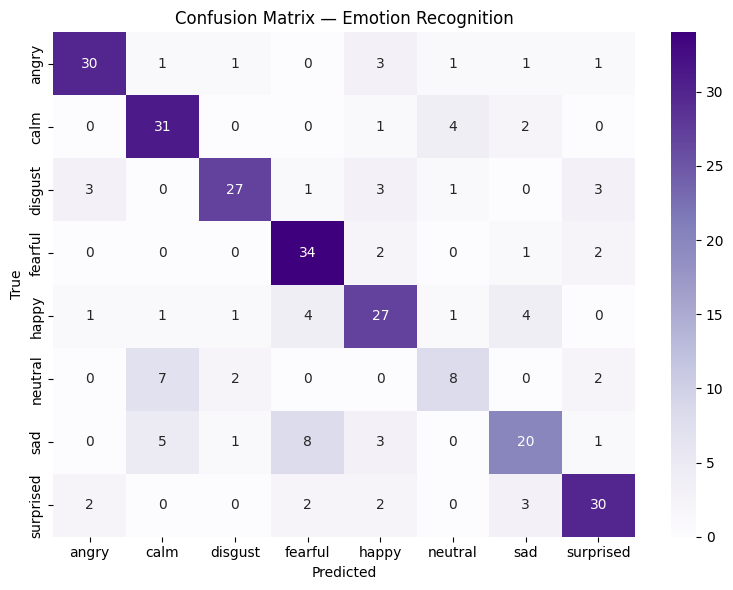

In [7]:
test_loss, test_acc = model.evaluate(X_test_s, y_test_cat, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

y_pred = np.argmax(model.predict(X_test_s), axis=1)
print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix — Emotion Recognition')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout(); plt.show()

In [8]:
model.save('emotion_recognition_model.keras')
import joblib
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le, 'label_encoder.pkl')

from google.colab import files
files.download('emotion_recognition_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>